# Tuned LightGBM + CatBoost + XGBoost Stack (v5)

Pipeline: Feature engineering -> **fold-local** importance-based feature selection -> Bayesian-tuned base models -> seed-averaged predictions -> Ridge/Lasso meta-learner.

Changes in v5:
1. Fixed leakage: feature selection now runs inside every CV fold (Optuna + OOF training)
2. LightGBM switched to MAE objective (`objective="regression_l1"`)
3. Optuna trials increased to 100/model/target with parallel trial execution (`n_jobs=-1`)
4. Categorical columns are explicitly cast to pandas `category` dtype for LightGBM
5. Stacked Outer-CV now fits meta-learner on each outer-train split before scoring outer-val

Validation: GroupKFold by patient `sub_id`.


In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
SEEDS = [42, 123, 7]
np.random.seed(SEED)
N_FOLDS = 5

## 1. Load Data & EDA

In [2]:
df_train = pd.read_csv("src_files/train_competition_2026.csv")
df_test = pd.read_csv("src_files/test_no_outcome.csv")

print(f"Raw train: {df_train.shape}")
print(f"Raw test:  {df_test.shape}")

Raw train: (432600, 18)
Raw test:  (103500, 16)


Looking at the target distributions to decide if we need any transformations (e.g., `log1p` for skewed targets).

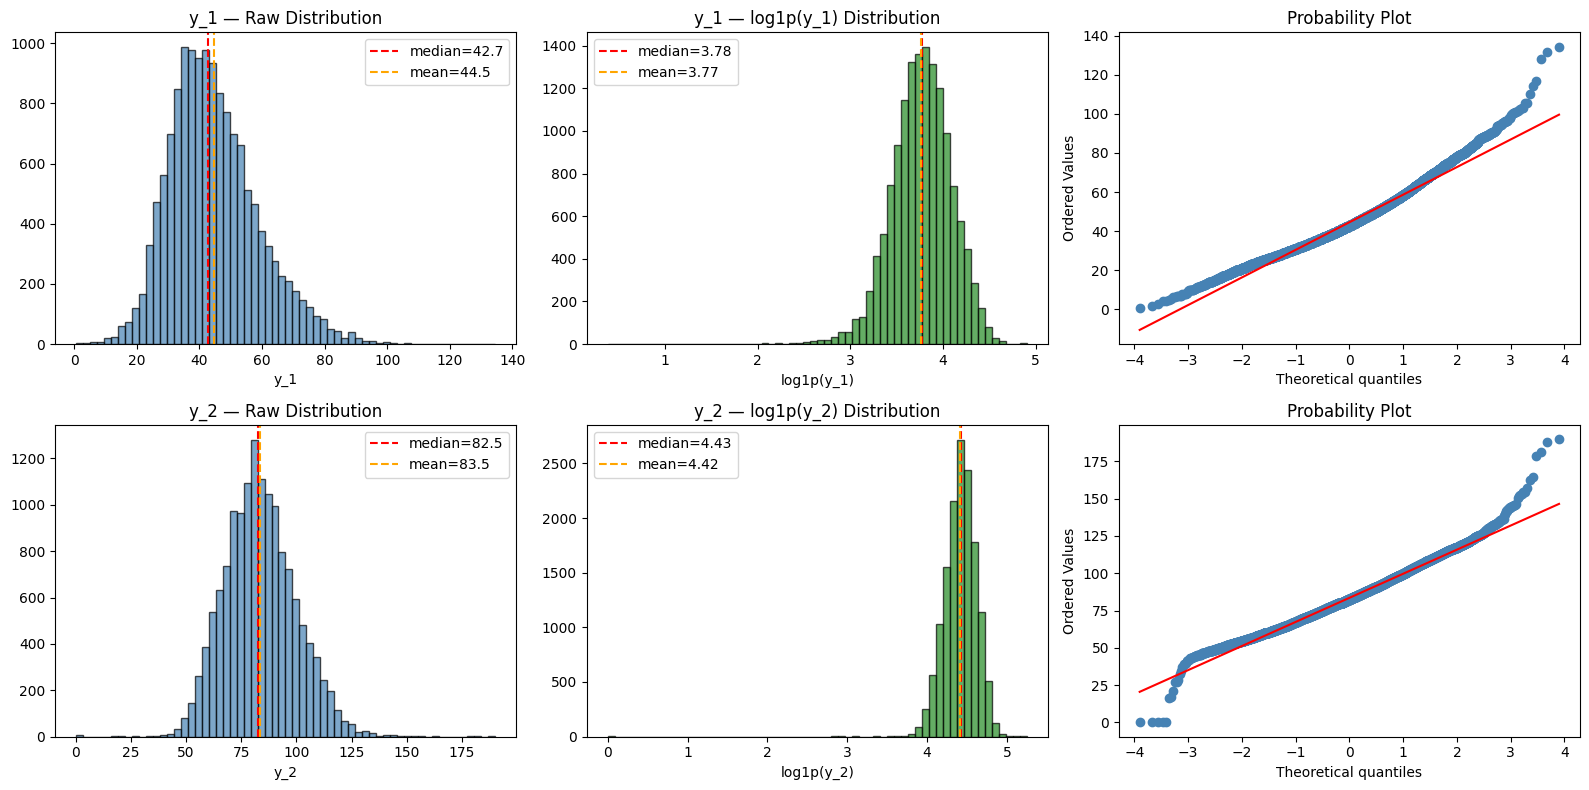

Target distribution summary:

  y_1:
    range: [0.5, 134.5], mean: 44.5, median: 42.7
    std: 14.3, skew: 0.676, kurtosis: 0.812
    log1p skew: -0.605

  y_2:
    range: [0.0, 190.0], mean: 83.5, median: 82.5
    std: 16.2, skew: 0.338, kurtosis: 0.748
    log1p skew: -3.415

=> y_1 is right-skewed — log1p transform will help.
=> y_2 is roughly symmetric — no transform needed.


In [3]:
y_train_eda = df_train.groupby("obs")[["y_1", "y_2"]].first()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].hist(y_train_eda["y_1"], bins=60, edgecolor="black", alpha=0.7, color="steelblue")
axes[0, 0].set_title("y_1 — Raw Distribution")
axes[0, 0].set_xlabel("y_1")
axes[0, 0].axvline(y_train_eda["y_1"].median(), color="red", ls="--", label=f'median={y_train_eda["y_1"].median():.1f}')
axes[0, 0].axvline(y_train_eda["y_1"].mean(), color="orange", ls="--", label=f'mean={y_train_eda["y_1"].mean():.1f}')
axes[0, 0].legend()

y1_log = np.log1p(y_train_eda["y_1"])
axes[0, 1].hist(y1_log, bins=60, edgecolor="black", alpha=0.7, color="forestgreen")
axes[0, 1].set_title("y_1 — log1p(y_1) Distribution")
axes[0, 1].set_xlabel("log1p(y_1)")
axes[0, 1].axvline(y1_log.median(), color="red", ls="--", label=f"median={y1_log.median():.2f}")
axes[0, 1].axvline(y1_log.mean(), color="orange", ls="--", label=f"mean={y1_log.mean():.2f}")
axes[0, 1].legend()

from scipy import stats
axes[0, 2].set_title("y_1 — QQ Plot (raw vs log1p)")
stats.probplot(y_train_eda["y_1"], dist="norm", plot=axes[0, 2])
axes[0, 2].get_lines()[0].set_color("steelblue")
axes[0, 2].get_lines()[0].set_label("raw")

axes[1, 0].hist(y_train_eda["y_2"], bins=60, edgecolor="black", alpha=0.7, color="steelblue")
axes[1, 0].set_title("y_2 — Raw Distribution")
axes[1, 0].set_xlabel("y_2")
axes[1, 0].axvline(y_train_eda["y_2"].median(), color="red", ls="--", label=f'median={y_train_eda["y_2"].median():.1f}')
axes[1, 0].axvline(y_train_eda["y_2"].mean(), color="orange", ls="--", label=f'mean={y_train_eda["y_2"].mean():.1f}')
axes[1, 0].legend()

y2_log = np.log1p(y_train_eda["y_2"])
axes[1, 1].hist(y2_log, bins=60, edgecolor="black", alpha=0.7, color="forestgreen")
axes[1, 1].set_title("y_2 — log1p(y_2) Distribution")
axes[1, 1].set_xlabel("log1p(y_2)")
axes[1, 1].axvline(y2_log.median(), color="red", ls="--", label=f"median={y2_log.median():.2f}")
axes[1, 1].axvline(y2_log.mean(), color="orange", ls="--", label=f"mean={y2_log.mean():.2f}")
axes[1, 1].legend()

axes[1, 2].set_title("y_2 — QQ Plot (raw)")
stats.probplot(y_train_eda["y_2"], dist="norm", plot=axes[1, 2])
axes[1, 2].get_lines()[0].set_color("steelblue")

plt.tight_layout()
plt.show()

from scipy.stats import skew, kurtosis
print("Target distribution summary:")
for col in ["y_1", "y_2"]:
    vals = y_train_eda[col]
    print(f"\n  {col}:")
    print(f"    range: [{vals.min():.1f}, {vals.max():.1f}], mean: {vals.mean():.1f}, median: {vals.median():.1f}")
    print(f"    std: {vals.std():.1f}, skew: {skew(vals):.3f}, kurtosis: {kurtosis(vals):.3f}")
    print(f"    log1p skew: {skew(np.log1p(vals)):.3f}")

print("\n=> y_1 is right-skewed — log1p transform will help.")
print("=> y_2 is roughly symmetric — no transform needed.")

## 2. Feature Engineering

Each observation is a ~30-row time series block. We collapse it into a single feature vector per observation using aggregation stats, temporal features, FFT, energy, cross-channel interactions, etc.

In [4]:
T_COLS = [c for c in df_train.columns if c.startswith("t_")]
NUM_COLS = [c for c in df_train.columns if c.startswith("num_")]
CAT_COLS = [c for c in df_train.columns if c.startswith("cat_")]
N_T = len(T_COLS)


def collapse_obs(df):
    obs_groups = df.groupby("obs")
    unique_obs = np.sort(df["obs"].unique())
    obs_idx = pd.Index(unique_obs, name="obs")
    n_obs = len(unique_obs)

    static = obs_groups[NUM_COLS + CAT_COLS].first()

    basic = obs_groups[T_COLS].agg(["mean", "std", "min", "max", "median", "first", "last"])
    basic.columns = [f"{f}_{a}" for f, a in basic.columns]

    quants = {}
    for q, label in [(0.10, "q10"), (0.25, "q25"), (0.75, "q75"), (0.90, "q90")]:
        qdf = obs_groups[T_COLS].quantile(q)
        qdf.columns = [f"{c}_{label}" for c in T_COLS]
        quants[label] = qdf

    iqr = quants["q75"].values - quants["q25"].values
    iqr_df = pd.DataFrame(iqr, index=obs_idx, columns=[f"{c}_iqr" for c in T_COLS])

    obs_size = obs_groups.size()
    max_len = obs_size.max()
    t_data = df[T_COLS].values

    padded = np.full((n_obs, max_len, N_T), np.nan)
    lengths = np.zeros(n_obs, dtype=int)
    row = 0
    for i in range(n_obs):
        n = obs_size.iloc[i]
        padded[i, :n, :] = t_data[row:row + n, :]
        lengths[i] = n
        row += n

    from scipy.stats import skew as sp_skew, kurtosis as sp_kurt
    skew_vals = np.zeros((n_obs, N_T))
    kurt_vals = np.zeros((n_obs, N_T))
    for i in range(n_obs):
        n = lengths[i]
        block = padded[i, :n, :]
        if n > 2:
            skew_vals[i] = sp_skew(block, axis=0, bias=False)
        if n > 3:
            kurt_vals[i] = sp_kurt(block, axis=0, bias=False)

    skew_df = pd.DataFrame(skew_vals, index=obs_idx, columns=[f"{c}_skew" for c in T_COLS])
    kurt_df = pd.DataFrame(kurt_vals, index=obs_idx, columns=[f"{c}_kurtosis" for c in T_COLS])

    delta_vals = np.zeros((n_obs, N_T))
    range_vals = np.zeros((n_obs, N_T))
    slope_vals = np.zeros((n_obs, N_T))
    slope_early = np.zeros((n_obs, N_T))
    slope_late = np.zeros((n_obs, N_T))

    for i in range(n_obs):
        n = lengths[i]
        block = padded[i, :n, :]
        delta_vals[i] = block[-1] - block[0]
        range_vals[i] = np.nanmax(block, axis=0) - np.nanmin(block, axis=0)
        if n > 1:
            x = np.arange(n, dtype=float)
            xm = x.mean()
            xv = np.sum((x - xm) ** 2)
            for j in range(N_T):
                slope_vals[i, j] = np.sum((x - xm) * (block[:, j] - block[:, j].mean())) / xv
        half = n // 2
        if n >= 4:
            xe = np.arange(half, dtype=float)
            if len(xe) >= 2:
                xem, xev = xe.mean(), np.sum((xe - xe.mean()) ** 2)
                for j in range(N_T):
                    seg = block[:half, j]
                    slope_early[i, j] = np.sum((xe - xem) * (seg - seg.mean())) / xev
            xl = np.arange(n - half, dtype=float)
            if len(xl) >= 2:
                xlm, xlv = xl.mean(), np.sum((xl - xl.mean()) ** 2)
                for j in range(N_T):
                    seg = block[half:n, j]
                    slope_late[i, j] = np.sum((xl - xlm) * (seg - seg.mean())) / xlv

    trend_df = pd.DataFrame(
        np.hstack([delta_vals, range_vals, slope_vals, slope_early, slope_late]),
        index=obs_idx,
        columns=(
            [f"{c}_delta" for c in T_COLS] + [f"{c}_range" for c in T_COLS]
            + [f"{c}_slope" for c in T_COLS] + [f"{c}_slope_early" for c in T_COLS]
            + [f"{c}_slope_late" for c in T_COLS]
        ),
    )

    early_means = np.zeros((n_obs, N_T))
    late_means = np.zeros((n_obs, N_T))
    last5_means = np.zeros((n_obs, N_T))
    for i in range(n_obs):
        n = lengths[i]
        half = n // 2
        early_means[i] = np.nanmean(padded[i, :half, :], axis=0)
        late_means[i] = np.nanmean(padded[i, half:n, :], axis=0)
        last5_means[i] = np.nanmean(padded[i, max(0, n - 5):n, :], axis=0)

    seg_df = pd.DataFrame(
        np.hstack([early_means, late_means, last5_means]),
        index=obs_idx,
        columns=(
            [f"{c}_early_mean" for c in T_COLS] + [f"{c}_late_mean" for c in T_COLS]
            + [f"{c}_last5_mean" for c in T_COLS]
        ),
    )

    volatility = np.zeros((n_obs, N_T))
    autocorr1 = np.zeros((n_obs, N_T))
    for i in range(n_obs):
        n = lengths[i]
        block = padded[i, :n, :]
        if n > 1:
            volatility[i] = np.mean(np.abs(np.diff(block, axis=0)), axis=0)
        if n >= 3:
            for j in range(N_T):
                s = block[:, j]
                if np.var(s) > 0:
                    autocorr1[i, j] = np.corrcoef(s[:-1], s[1:])[0, 1]

    dyn_df = pd.DataFrame(
        np.hstack([volatility, np.nan_to_num(autocorr1, 0.0)]),
        index=obs_idx,
        columns=[f"{c}_volatility" for c in T_COLS] + [f"{c}_autocorr1" for c in T_COLS],
    )

    fft_mag1 = np.zeros((n_obs, N_T))
    fft_mag2 = np.zeros((n_obs, N_T))
    fft_freq1 = np.zeros((n_obs, N_T))
    fft_freq2 = np.zeros((n_obs, N_T))
    for i in range(n_obs):
        n = lengths[i]
        if n >= 4:
            for j in range(N_T):
                s = padded[i, :n, j]
                s_detrended = s - np.linspace(s[0], s[-1], n)
                fft_vals = np.abs(np.fft.rfft(s_detrended))[1:]
                freqs = np.fft.rfftfreq(n, d=1.0)[1:]
                if len(fft_vals) >= 2:
                    top2 = np.argsort(fft_vals)[-2:]
                    fft_mag1[i, j] = fft_vals[top2[-1]]
                    fft_freq1[i, j] = freqs[top2[-1]]
                    fft_mag2[i, j] = fft_vals[top2[-2]]
                    fft_freq2[i, j] = freqs[top2[-2]]
                elif len(fft_vals) == 1:
                    fft_mag1[i, j] = fft_vals[0]
                    fft_freq1[i, j] = freqs[0]

    fft_df = pd.DataFrame(
        np.hstack([fft_mag1, fft_mag2, fft_freq1, fft_freq2]),
        index=obs_idx,
        columns=(
            [f"{c}_fft_mag1" for c in T_COLS] + [f"{c}_fft_mag2" for c in T_COLS]
            + [f"{c}_fft_freq1" for c in T_COLS] + [f"{c}_fft_freq2" for c in T_COLS]
        ),
    )

    energy = np.zeros((n_obs, N_T))
    rms = np.zeros((n_obs, N_T))
    for i in range(n_obs):
        n = lengths[i]
        block = padded[i, :n, :]
        energy[i] = np.sum(block ** 2, axis=0)
        rms[i] = np.sqrt(np.mean(block ** 2, axis=0))

    energy_df = pd.DataFrame(
        np.hstack([energy, rms]),
        index=obs_idx,
        columns=[f"{c}_energy" for c in T_COLS] + [f"{c}_rms" for c in T_COLS],
    )

    obs_length = obs_size.rename("obs_length")

    result = pd.concat(
        [static, basic, *quants.values(), iqr_df, skew_df, kurt_df,
         trend_df, seg_df, dyn_df, fft_df, energy_df, obs_length],
        axis=1,
    ).reset_index()

    from itertools import combinations
    for c1, c2 in combinations(T_COLS, 2):
        result[f"{c1}_{c2}_mean_diff"] = result[f"{c1}_mean"] - result[f"{c2}_mean"]
        denom = result[f"{c2}_mean"].replace(0, np.nan)
        result[f"{c1}_{c2}_mean_ratio"] = result[f"{c1}_mean"] / denom

    t_pairs = list(combinations(range(N_T), 2))
    corr_data = np.zeros((n_obs, len(t_pairs)))
    for idx, (j1, j2) in enumerate(t_pairs):
        for i in range(n_obs):
            n = lengths[i]
            if n > 2:
                s1, s2 = padded[i, :n, j1], padded[i, :n, j2]
                if s1.std() > 0 and s2.std() > 0:
                    corr_data[i, idx] = np.corrcoef(s1, s2)[0, 1]

    corr_cols = [f"{T_COLS[j1]}_{T_COLS[j2]}_corr" for j1, j2 in t_pairs]
    for ci, col_name in enumerate(corr_cols):
        result[col_name] = corr_data[:, ci]

    result = result.fillna(0.0)

    return result


print("Collapsing observations...")
X_train_df = collapse_obs(df_train)
X_test_df = collapse_obs(df_test)

y_train = df_train.groupby("obs")[["y_1", "y_2"]].first().reset_index(drop=True)
obs_to_patient = df_train.groupby("obs")["sub_id"].first().reset_index(drop=True)

test_obs = X_test_df["obs"].copy()
X_train_all = X_train_df.drop(columns=["obs"]).copy()
X_test_all = X_test_df.drop(columns=["obs"]).copy()


def cast_categorical_columns(train_df, test_df, cat_cols):
    for col in cat_cols:
        if col not in train_df.columns:
            continue
        all_vals = pd.concat([train_df[col], test_df[col]], axis=0)
        categories = pd.Index(all_vals.dropna().unique())
        cat_dtype = pd.CategoricalDtype(categories=categories)
        train_df[col] = train_df[col].astype(cat_dtype)
        test_df[col] = test_df[col].astype(cat_dtype)
    return train_df, test_df


X_train_all, X_test_all = cast_categorical_columns(X_train_all, X_test_all, CAT_COLS)

assert list(X_train_all.columns) == list(X_test_all.columns), "Column mismatch!"
assert X_train_all.isna().sum().sum() == 0, "Train has NaNs!"
assert X_test_all.isna().sum().sum() == 0, "Test has NaNs!"

CAT_FEATURE_NAMES = [c for c in CAT_COLS if c in X_train_all.columns]

print(f"Train: {X_train_all.shape[0]} obs x {X_train_all.shape[1]} features")
print(f"Test:  {X_test_all.shape[0]} obs x {X_test_all.shape[1]} features")
print(f"Unique patients: {obs_to_patient.nunique()}")
print(f"Categorical cols cast to category dtype: {len(CAT_FEATURE_NAMES)}")


Collapsing observations...
Train: 14420 obs x 189 features
Test:  3450 obs x 189 features
Unique patients: 1596
Categorical cols cast to category dtype: 5


## 3. Feature Selection

Feature selection is now leak-safe:
- We define a LightGBM importance selector (`TOP_K=100` + static `num_*`/`cat_*`).
- For any CV/Optuna fold, features are selected using only that fold's training split.
- The selected mask is then applied to that fold's validation split.

A full-data feature importance plot is still shown for diagnostics only.


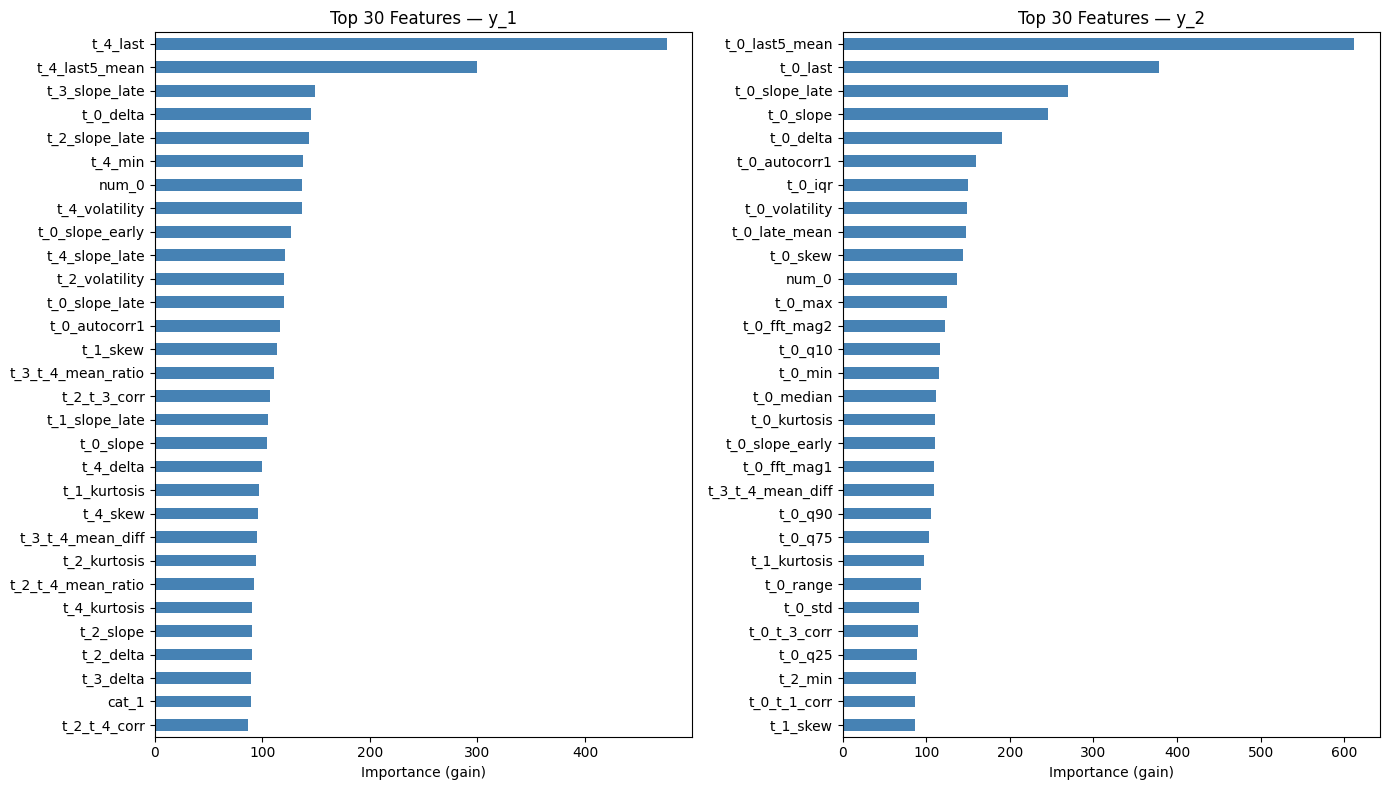


Feature selection preview (full data): 189 -> 126 features
  Dropped: 63 noise features
  Note: CV and Optuna use fold-local feature selection to avoid leakage.
  Final train preview: (14420, 126)
  Final test preview:  (3450, 126)


In [5]:
TOP_K = 100


def select_features_fold(X_fold_train, y_fold_train, top_k=TOP_K, seed=SEED):
    cat_fold = [c for c in CAT_COLS if c in X_fold_train.columns]

    selector = lgb.LGBMRegressor(
        objective="regression_l1",
        metric="l1",
        n_estimators=500,
        learning_rate=0.03,
        max_depth=5,
        num_leaves=31,
        subsample=0.7,
        colsample_bytree=0.6,
        verbosity=-1,
        random_state=seed,
        n_jobs=-1,
    )

    fit_kwargs = {}
    if cat_fold:
        fit_kwargs["categorical_feature"] = cat_fold

    selector.fit(X_fold_train, y_fold_train, **fit_kwargs)

    importance = pd.Series(
        selector.feature_importances_, index=X_fold_train.columns
    ).sort_values(ascending=False)

    selected = set(importance.head(top_k).index.tolist())
    selected.update([c for c in NUM_COLS + CAT_COLS if c in X_fold_train.columns])

    return sorted(selected), importance


# Diagnostic-only view using full data (CV/tuning still use fold-local selection)
important_features = set()
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for i, target in enumerate(["y_1", "y_2"]):
    selected_fold, importance = select_features_fold(X_train_all, y_train[target], top_k=TOP_K, seed=SEED)
    important_features.update(selected_fold)

    importance.head(30).plot.barh(ax=axes[i], color="steelblue")
    axes[i].set_title(f"Top 30 Features — {target}")
    axes[i].invert_yaxis()
    axes[i].set_xlabel("Importance (gain)")

plt.tight_layout()
plt.show()

selected_features_full = sorted(important_features)

print()
print(f"Feature selection preview (full data): {X_train_all.shape[1]} -> {len(selected_features_full)} features")
print(f"  Dropped: {X_train_all.shape[1] - len(selected_features_full)} noise features")
print("  Note: CV and Optuna use fold-local feature selection to avoid leakage.")

X_train_sel = X_train_all[selected_features_full].copy()
X_test_sel = X_test_all[selected_features_full].copy()
CAT_FEATURE_NAMES = [c for c in CAT_COLS if c in selected_features_full]

print(f"  Final train preview: {X_train_sel.shape}")
print(f"  Final test preview:  {X_test_sel.shape}")


## 4. Bayesian Hyperparameter Tuning (Optuna)

Tuning all 3 models per target with GroupKFold.  
Feature selection is performed inside each tuning fold (training split only), then applied to the fold validation split.

LightGBM is optimized with MAE loss (`regression_l1`).  
Optuna trials are increased to 100 per model/target and run in parallel (`n_jobs=-1`).


In [6]:
TUNE_FOLDS = 3
N_TRIALS_LGBM = 100
N_TRIALS_CB = 100
N_TRIALS_XGB = 100
OPTUNA_N_JOBS = -1

USE_LOG1P = {"y_1": True, "y_2": False}


def transform_target(y, target):
    if USE_LOG1P.get(target, False):
        return np.log1p(y)
    return y


def inverse_transform_target(y, target):
    if USE_LOG1P.get(target, False):
        return np.expm1(y)
    return y


def build_tune_fold_cache(X, y_t, groups, seed=SEED):
    gkf = GroupKFold(n_splits=TUNE_FOLDS)
    cache = []
    for tr_idx, val_idx in gkf.split(X, y_t, groups=groups):
        selected_features, _ = select_features_fold(
            X.iloc[tr_idx], y_t.iloc[tr_idx], top_k=TOP_K, seed=seed
        )
        cat_fold = [c for c in CAT_COLS if c in selected_features]
        cache.append((tr_idx, val_idx, selected_features, cat_fold))
    return cache


def objective_lgbm(trial, X, y, fold_cache, target):
    params = {
        "objective": "regression_l1",
        "metric": "mae",
        "verbosity": -1,
        "n_estimators": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.008, 0.08, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 40),
        "subsample": trial.suggest_float("subsample", 0.5, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 0.8),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.01, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.01, 5.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.5),
        "random_state": SEED,
        "n_jobs": 1,
    }

    y_t = transform_target(y, target)
    maes = []

    for tr_idx, val_idx, selected_features, cat_fold in fold_cache:
        X_tr = X.iloc[tr_idx][selected_features]
        X_val = X.iloc[val_idx][selected_features]

        model = lgb.LGBMRegressor(**params)
        fit_kwargs = {}
        if cat_fold:
            fit_kwargs["categorical_feature"] = cat_fold

        model.fit(
            X_tr,
            y_t.iloc[tr_idx],
            eval_set=[(X_val, y_t.iloc[val_idx])],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
            **fit_kwargs,
        )

        preds = inverse_transform_target(model.predict(X_val), target)
        maes.append(mean_absolute_error(y.iloc[val_idx], preds))

    return np.mean(maes)


def objective_xgb(trial, X, y, fold_cache, target):
    params = {
        "n_estimators": 1000,
        "tree_method": "hist",
        "enable_categorical": True,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "min_child_weight": trial.suggest_int("min_child_weight", 3, 15),
        "subsample": trial.suggest_float("subsample", 0.5, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 0.8),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.01, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 5.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
        "early_stopping_rounds": 50,
        "random_state": SEED,
        "n_jobs": 1,
    }

    y_t = transform_target(y, target)
    maes = []

    for tr_idx, val_idx, selected_features, _ in fold_cache:
        X_tr = X.iloc[tr_idx][selected_features]
        X_val = X.iloc[val_idx][selected_features]

        model = xgb.XGBRegressor(**params)
        model.fit(
            X_tr,
            y_t.iloc[tr_idx],
            eval_set=[(X_val, y_t.iloc[val_idx])],
            verbose=False,
        )

        preds = inverse_transform_target(model.predict(X_val), target)
        maes.append(mean_absolute_error(y.iloc[val_idx], preds))

    return np.mean(maes)


def objective_catboost(trial, X, y, fold_cache, target):
    params = {
        "iterations": 1000,
        "loss_function": "RMSE",
        "eval_metric": "MAE",
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.08, log=True),
        "depth": trial.suggest_int("depth", 4, 7),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 0.5, 5.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 0.9),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 35),
        "random_strength": trial.suggest_float("random_strength", 0.5, 5.0, log=True),
        "random_seed": SEED,
        "verbose": 0,
        "allow_writing_files": False,
        "early_stopping_rounds": 50,
        "thread_count": 1,
    }

    y_t = transform_target(y, target)
    maes = []

    for tr_idx, val_idx, selected_features, cat_fold in fold_cache:
        X_tr = X.iloc[tr_idx][selected_features]
        X_val = X.iloc[val_idx][selected_features]
        cat_indices = [X_tr.columns.get_loc(c) for c in cat_fold]

        model = CatBoostRegressor(**params, cat_features=cat_indices)
        model.fit(
            X_tr,
            y_t.iloc[tr_idx],
            eval_set=(X_val, y_t.iloc[val_idx]),
            verbose=0,
        )

        preds = inverse_transform_target(model.predict(X_val), target)
        maes.append(mean_absolute_error(y.iloc[val_idx], preds))

    return np.mean(maes)


best_params = {"lgbm": {}, "xgb": {}, "catboost": {}}

for target in ["y_1", "y_2"]:
    y_target = y_train[target]
    y_target_t = transform_target(y_target, target)
    fold_cache = build_tune_fold_cache(X_train_all, y_target_t, obs_to_patient, seed=SEED)
    log_str = " (log1p space)" if USE_LOG1P[target] else ""

    print(f"\nTuning LightGBM for {target}{log_str} ({N_TRIALS_LGBM} trials, n_jobs={OPTUNA_N_JOBS})...")
    study_lgbm = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study_lgbm.optimize(
        lambda trial: objective_lgbm(trial, X_train_all, y_target, fold_cache, target),
        n_trials=N_TRIALS_LGBM,
        n_jobs=OPTUNA_N_JOBS,
    )
    best_params["lgbm"][target] = study_lgbm.best_params
    print(f"  Best MAE: {study_lgbm.best_value:.4f}")
    print(f"  Best params: {study_lgbm.best_params}")

    print(f"\nTuning XGBoost for {target}{log_str} ({N_TRIALS_XGB} trials, n_jobs={OPTUNA_N_JOBS})...")
    study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study_xgb.optimize(
        lambda trial: objective_xgb(trial, X_train_all, y_target, fold_cache, target),
        n_trials=N_TRIALS_XGB,
        n_jobs=OPTUNA_N_JOBS,
    )
    best_params["xgb"][target] = study_xgb.best_params
    print(f"  Best MAE: {study_xgb.best_value:.4f}")
    print(f"  Best params: {study_xgb.best_params}")

    print(f"\nTuning CatBoost for {target}{log_str} ({N_TRIALS_CB} trials, n_jobs={OPTUNA_N_JOBS})...")
    study_cb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study_cb.optimize(
        lambda trial: objective_catboost(trial, X_train_all, y_target, fold_cache, target),
        n_trials=N_TRIALS_CB,
        n_jobs=OPTUNA_N_JOBS,
    )
    best_params["catboost"][target] = study_cb.best_params
    print(f"  Best MAE: {study_cb.best_value:.4f}")
    print(f"  Best params: {study_cb.best_params}")

print("\n" + "=" * 60)
print("Tuning complete!")
print("=" * 60)



Tuning LightGBM for y_1 (log1p space) (100 trials, n_jobs=-1)...
  Best MAE: 4.8773
  Best params: {'learning_rate': 0.028056186211933634, 'max_depth': 3, 'num_leaves': 88, 'min_child_samples': 20, 'subsample': 0.8786014949581485, 'colsample_bytree': 0.4079889000773307, 'reg_alpha': 0.09375138096847661, 'reg_lambda': 0.012850055966991599, 'min_split_gain': 0.33402322370850346}

Tuning XGBoost for y_1 (log1p space) (100 trials, n_jobs=-1)...
  Best MAE: 4.9819
  Best params: {'learning_rate': 0.010011136544156264, 'max_depth': 3, 'min_child_weight': 6, 'subsample': 0.7864328512051386, 'colsample_bytree': 0.4594830758712937, 'reg_alpha': 0.9079371956506257, 'reg_lambda': 1.0372141390278262, 'gamma': 0.020688172776539893}

Tuning CatBoost for y_1 (log1p space) (100 trials, n_jobs=-1)...
  Best MAE: 4.9764
  Best params: {'learning_rate': 0.020006806475112698, 'depth': 7, 'l2_leaf_reg': 3.5969629320435055, 'subsample': 0.6478632227508077, 'colsample_bylevel': 0.6072414645881918, 'min_data

## 5. Train Final Models + OOF Predictions

Using tuned params from Optuna.  
For each fold, we re-run feature selection on that fold's training split only, then train/predict on the fold-specific selected feature set.  
Each model is seed-averaged (3 seeds). GroupKFold OOF predictions become meta-features.


In [7]:
gkf = GroupKFold(n_splits=N_FOLDS)
fold_splits = list(gkf.split(X_train_all, y_train["y_1"], groups=obs_to_patient))

ALL_MODELS = ["lgbm", "xgb", "catboost"]

oof_preds = {t: {} for t in ["y_1", "y_2"]}
test_preds = {t: {} for t in ["y_1", "y_2"]}

for target in ["y_1", "y_2"]:
    y_target = y_train[target]
    y_target_t = transform_target(y_target, target)
    log_str = " (log1p)" if USE_LOG1P[target] else ""

    fold_feature_cache = []
    for tr_idx, val_idx in fold_splits:
        selected_features, _ = select_features_fold(
            X_train_all.iloc[tr_idx], y_target_t.iloc[tr_idx], top_k=TOP_K, seed=SEED
        )
        cat_fold = [c for c in CAT_COLS if c in selected_features]
        fold_feature_cache.append((tr_idx, val_idx, selected_features, cat_fold))

    print(f"\n{'=' * 50}")
    print(f"Training for {target}{log_str}")
    print(f"{'=' * 50}")

    for model_name in ALL_MODELS:
        oof_seed_sum = np.zeros(len(X_train_all))
        test_seed_sum = np.zeros(len(X_test_all))

        for seed in SEEDS:
            oof = np.zeros(len(X_train_all))
            test_fold_preds = []
            bp = best_params[model_name][target]

            for tr_idx, val_idx, selected_features, cat_fold in fold_feature_cache:
                X_tr = X_train_all.iloc[tr_idx][selected_features]
                y_tr = y_target_t.iloc[tr_idx]
                X_val = X_train_all.iloc[val_idx][selected_features]
                y_val = y_target_t.iloc[val_idx]
                X_te = X_test_all[selected_features]

                if model_name == "lgbm":
                    model = lgb.LGBMRegressor(
                        objective="regression_l1",
                        metric="mae",
                        n_estimators=1000,
                        verbosity=-1,
                        random_state=seed,
                        n_jobs=-1,
                        **bp,
                    )
                    fit_kwargs = {}
                    if cat_fold:
                        fit_kwargs["categorical_feature"] = cat_fold

                    model.fit(
                        X_tr,
                        y_tr,
                        eval_set=[(X_val, y_val)],
                        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
                        **fit_kwargs,
                    )
                elif model_name == "xgb":
                    model = xgb.XGBRegressor(
                        n_estimators=1000,
                        tree_method="hist",
                        enable_categorical=True,
                        early_stopping_rounds=50,
                        random_state=seed,
                        n_jobs=-1,
                        **bp,
                    )
                    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
                else:
                    cat_indices_fold = [X_tr.columns.get_loc(c) for c in cat_fold]
                    model = CatBoostRegressor(
                        iterations=1000,
                        loss_function="RMSE",
                        eval_metric="MAE",
                        cat_features=cat_indices_fold,
                        random_seed=seed,
                        verbose=0,
                        allow_writing_files=False,
                        early_stopping_rounds=50,
                        thread_count=-1,
                        **bp,
                    )
                    model.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=0)

                oof[val_idx] = model.predict(X_val)
                test_fold_preds.append(model.predict(X_te))

            oof_seed_sum += oof
            test_seed_sum += np.mean(test_fold_preds, axis=0)

        oof_avg_t = oof_seed_sum / len(SEEDS)
        test_avg_t = test_seed_sum / len(SEEDS)

        oof_preds[target][model_name] = inverse_transform_target(oof_avg_t, target)
        test_preds[target][model_name] = inverse_transform_target(test_avg_t, target)

        oof_mae = mean_absolute_error(y_target, oof_preds[target][model_name])
        print(f"  {model_name} {target} OOF MAE (seed-avg): {oof_mae:.4f}")



Training for y_1 (log1p)
  lgbm y_1 OOF MAE (seed-avg): 4.8530
  xgb y_1 OOF MAE (seed-avg): 4.9771
  catboost y_1 OOF MAE (seed-avg): 4.9651

Training for y_2
  lgbm y_2 OOF MAE (seed-avg): 3.3084
  xgb y_2 OOF MAE (seed-avg): 3.3847
  catboost y_2 OOF MAE (seed-avg): 3.3682


## 6. Meta-Learner (Stacking)

Stack the 3 base model OOF predictions with Ridge or Lasso, selected via CV. Operates in original scale (OOF predictions are already inverse-transformed).

In [12]:
from itertools import combinations

MODEL_NAMES = ALL_MODELS  # ["lgbm", "xgb", "catboost"]

# combos to evaluate (pairs + all 3)
COMBO_SIZES = [2, 3]
combo_defs = {}
for r in COMBO_SIZES:
    for combo in combinations(MODEL_NAMES, r):
        combo_name = "+".join(combo)
        combo_defs[combo_name] = list(combo)

print("Combos:")
for k, v in combo_defs.items():
    print(f"  {k}: {v}")

# Train one stacked meta model per target per combo
meta_models = {t: {} for t in ["y_1", "y_2"]}
meta_cv_scores = {t: {} for t in ["y_1", "y_2"]}

for target in ["y_1", "y_2"]:
    y_target = y_train[target].values

    for combo_name, members in combo_defs.items():
        S_train = np.column_stack([oof_preds[target][m] for m in members])

        candidates = {}
        for alpha in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
            candidates[f"Ridge({alpha})"] = Ridge(alpha=alpha)
        for alpha in [0.001, 0.01, 0.1]:
            candidates[f"Lasso({alpha})"] = Lasso(alpha=alpha, max_iter=5000)

        best_score = float("inf")
        best_name = None

        meta_gkf = GroupKFold(n_splits=3)
        for name, meta in candidates.items():
            scores = []
            for tr_idx, val_idx in meta_gkf.split(S_train, y_target, groups=obs_to_patient):
                m = type(meta)(**meta.get_params())
                m.fit(S_train[tr_idx], y_target[tr_idx])
                preds = m.predict(S_train[val_idx])
                scores.append(mean_absolute_error(y_target[val_idx], preds))
            mean_score = np.mean(scores)
            if mean_score < best_score:
                best_score = mean_score
                best_name = name

        best_meta = type(candidates[best_name])(**candidates[best_name].get_params())
        best_meta.fit(S_train, y_target)

        meta_models[target][combo_name] = best_meta
        meta_cv_scores[target][combo_name] = best_score

        if hasattr(best_meta, "coef_"):
            w = dict(zip(members, np.round(best_meta.coef_, 4)))
            print(f"{target} | stacked:{combo_name} -> {best_name}, CV MAE={best_score:.4f}, weights={w}")
        else:
            print(f"{target} | stacked:{combo_name} -> {best_name}, CV MAE={best_score:.4f}")


Combos:
  lgbm+xgb: ['lgbm', 'xgb']
  lgbm+catboost: ['lgbm', 'catboost']
  xgb+catboost: ['xgb', 'catboost']
  lgbm+xgb+catboost: ['lgbm', 'xgb', 'catboost']
y_1 | stacked:lgbm+xgb -> Lasso(0.01), CV MAE=4.9359, weights={'lgbm': np.float64(0.4461), 'xgb': np.float64(0.548)}
y_1 | stacked:lgbm+catboost -> Lasso(0.01), CV MAE=4.9279, weights={'lgbm': np.float64(0.4269), 'catboost': np.float64(0.5684)}
y_1 | stacked:xgb+catboost -> Ridge(0.001), CV MAE=4.9740, weights={'xgb': np.float64(0.4312), 'catboost': np.float64(0.5869)}
y_1 | stacked:lgbm+xgb+catboost -> Ridge(0.001), CV MAE=4.9314, weights={'lgbm': np.float64(0.3888), 'xgb': np.float64(0.1763), 'catboost': np.float64(0.4325)}
y_2 | stacked:lgbm+xgb -> Lasso(0.01), CV MAE=3.3309, weights={'lgbm': np.float64(0.4943), 'xgb': np.float64(0.5047)}
y_2 | stacked:lgbm+catboost -> Lasso(0.01), CV MAE=3.3258, weights={'lgbm': np.float64(0.4232), 'catboost': np.float64(0.5775)}
y_2 | stacked:xgb+catboost -> Ridge(0.001), CV MAE=3.3581, weig

## 7. Outer-CV Evaluation

Honest comparison across methods using the same GroupKFold splits.  
Stacked predictions are scored with fold-local meta-learner fitting (train-on-outer-train, predict-on-outer-val).


In [14]:
outer_gkf = GroupKFold(n_splits=N_FOLDS)
outer_splits = list(outer_gkf.split(X_train_all, y_train["y_1"], groups=obs_to_patient))

# methods:
# - single:<model>
# - avg:<combo>
# - stacked:<combo>
method_defs = []
for m in MODEL_NAMES:
    method_defs.append(("single", m, [m]))

for combo_name, members in combo_defs.items():
    method_defs.append(("avg", f"avg:{combo_name}", members))
    method_defs.append(("stacked", f"stacked:{combo_name}", members))

outer_scores = {t: {method_name: [] for _, method_name, _ in method_defs} for t in ["y_1", "y_2"]}

for fold_i, (tr_idx, val_idx) in enumerate(outer_splits):
    print(f"\nOuter fold {fold_i+1}/{N_FOLDS} (train={len(tr_idx)}, val={len(val_idx)})")

    for target in ["y_1", "y_2"]:
        y_full = y_train[target].values
        y_val = y_full[val_idx]

        for kind, method_name, members in method_defs:
            if kind == "single":
                preds = oof_preds[target][members[0]][val_idx]

            elif kind == "avg":
                S_val = np.column_stack([oof_preds[target][m][val_idx] for m in members])
                preds = S_val.mean(axis=1)

            else:  # stacked
                combo_name = method_name.split(":", 1)[1]
                S_full = np.column_stack([oof_preds[target][m] for m in members])

                meta_fold = type(meta_models[target][combo_name])(**meta_models[target][combo_name].get_params())
                meta_fold.fit(S_full[tr_idx], y_full[tr_idx])
                preds = meta_fold.predict(S_full[val_idx])

            outer_scores[target][method_name].append(mean_absolute_error(y_val, preds))


def pretty_method(name):
    pretty = {"lgbm": "LightGBM", "xgb": "XGBoost", "catboost": "CatBoost"}
    if name in pretty:
        return pretty[name]
    kind, combo = name.split(":", 1)
    members_txt = " + ".join(pretty.get(m, m) for m in combo.split("+"))
    return f"{kind.upper()} ({members_txt})"


rows = []
for _, method_name, _ in method_defs:
    y1_mae = np.mean(outer_scores["y_1"][method_name])
    y2_mae = np.mean(outer_scores["y_2"][method_name])
    rows.append({
        "Method": method_name,
        "Display": pretty_method(method_name),
        "y_1 MAE": y1_mae,
        "y_2 MAE": y2_mae,
        "Mean MAE": (y1_mae + y2_mae) / 2
    })

results_df = pd.DataFrame(rows).sort_values("Mean MAE").reset_index(drop=True)
best_method = results_df.loc[0, "Method"]

print("\n" + "=" * 80)
print("OUTER-CV MAE (singles + avg combos + stacked combos)")
print("=" * 80)
print(results_df[["Display", "y_1 MAE", "y_2 MAE", "Mean MAE"]].to_string(index=False, float_format="{:.4f}".format))
print("-" * 80)
print(f"Best method: {best_method}  ({pretty_method(best_method)})")
print("-" * 80)



Outer fold 1/5 (train=11536, val=2884)

Outer fold 2/5 (train=11536, val=2884)

Outer fold 3/5 (train=11536, val=2884)

Outer fold 4/5 (train=11536, val=2884)

Outer fold 5/5 (train=11536, val=2884)

OUTER-CV MAE (singles + avg combos + stacked combos)
                                Display  y_1 MAE  y_2 MAE  Mean MAE
                               LightGBM   4.8530   3.3084    4.0807
              AVG (LightGBM + CatBoost)   4.8785   3.3117    4.0951
               AVG (LightGBM + XGBoost)   4.8861   3.3184    4.1023
    AVG (LightGBM + XGBoost + CatBoost)   4.9030   3.3276    4.1153
          STACKED (LightGBM + CatBoost)   4.9337   3.3257    4.1297
STACKED (LightGBM + XGBoost + CatBoost)   4.9383   3.3291    4.1337
           STACKED (LightGBM + XGBoost)   4.9421   3.3301    4.1361
                               CatBoost   4.9651   3.3682    4.1667
           STACKED (XGBoost + CatBoost)   4.9789   3.3559    4.1674
               AVG (XGBoost + CatBoost)   4.9654   3.3709    4.168

## 8. Submission

In [15]:
# Set to None to auto-use best from Section 7.
# Examples:
# FORCE_METHOD = "lgbm"
# FORCE_METHOD = "avg:lgbm+catboost"
# FORCE_METHOD = "stacked:lgbm+xgb"
FORCE_METHOD = None

selected_method = FORCE_METHOD if FORCE_METHOD is not None else best_method
print(f"Using method: {selected_method}")


def predict_test_with_method(target, method_name):
    if method_name in MODEL_NAMES:
        return test_preds[target][method_name]

    kind, combo_name = method_name.split(":", 1)
    members = combo_defs[combo_name]
    S_test = np.column_stack([test_preds[target][m] for m in members])

    if kind == "avg":
        return S_test.mean(axis=1)
    if kind == "stacked":
        return meta_models[target][combo_name].predict(S_test)

    raise ValueError(f"Unknown method: {method_name}")


submission = pd.DataFrame({"obs": test_obs})
for target in ["y_1", "y_2"]:
    submission[target] = predict_test_with_method(target, selected_method)

for target in ["y_1", "y_2"]:
    train_vals = y_train[target]
    pred_vals = submission[target]
    print(f"{target}:")
    print(f"  Train - mean: {train_vals.mean():.2f}, std: {train_vals.std():.2f}, range: [{train_vals.min():.1f}, {train_vals.max():.1f}]")
    print(f"  Preds - mean: {pred_vals.mean():.2f}, std: {pred_vals.std():.2f}, range: [{pred_vals.min():.1f}, {pred_vals.max():.1f}]")

safe_name = selected_method.replace(":", "__").replace("+", "_")
out_file = f"james_v5_submission_{safe_name}.csv"
submission.to_csv(out_file, index=False)
print(f"\nSaved: {out_file} ({submission.shape[0]} rows)")
submission.head(10)


Using method: lgbm
y_1:
  Train - mean: 44.50, std: 14.31, range: [0.5, 134.5]
  Preds - mean: 41.81, std: 12.21, range: [10.9, 89.8]
y_2:
  Train - mean: 83.51, std: 16.23, range: [0.0, 190.0]
  Preds - mean: 82.27, std: 15.39, range: [46.5, 143.0]

Saved: james_v5_submission_lgbm.csv (3450 rows)


,obs,y_1,y_2
0,18,40.414312,105.188138
1,19,32.075605,100.450200
2,20,35.267338,96.489182
3,21,33.710904,94.731540
4,22,33.506890,94.235108
5,23,31.173825,56.259259
6,24,43.304700,57.176318
7,25,33.890835,53.162323
8,26,37.563647,46.683265
9,27,32.772690,47.096061
